# Этап 0. Подготовка

## Text Autocompletion for Social Media

![Project Status](https://img.shields.io/badge/status-in_progress-yellow.svg)
![Python Version](https://img.shields.io/badge/python-3.10-blue.svg)
![License](https://img.shields.io/badge/license-MIT-green.svg)

### Общее описание задачи

Проект направлен на создание системы автодополнения текста для социального приложения. Система должна предсказывать продолжение текста на основе начальных слов, помогая пользователям быстрее создавать посты.

#### Примеры работы системы:

| Входной текст (префикс)       | Предсказанное автодополнение        | Потенциальное приложение                |
|-------------------------------|-------------------------------------|-----------------------------------------|
| Я собираюсь                   | купить продукты                     | Клавиатура или сообщения                |
| Увидимся                      | завтра                              | Смарт-ответ в мессенджере               |
| Как приготовить               | пасту за 10 минут                   | Поисковая строка или YouTube            |
| Погода в Москве завтра        | будет солнечной и тёплой            | Поисковая строка                        |
| Можешь помочь мне             | с домашним заданием                 | Голосовой ассистент или чат-бот         |
| Жил-был однажды               | одинокий дракон                     | Генерация историй                       |
| Думаю, нам стоит              | выбрать второй вариант              | Email-композитор                        |
| Не забудь взять               | паспорт и посадочный талон          | Автоподсказка в почтовом клиенте        |

### Бизнес-контекст

В социальном приложении с короткими текстовыми постами необходимо реализовать функцию автодополнения текста. Ключевое требование — модель должна быть легковесной для запуска на мобильных устройствах с ограниченными ресурсами по памяти и вычислительной мощности.

### Формальная задача

1. Подготовить и очистить датасет с короткими текстовыми постами
2. Реализовать и обучить легковесную модель на основе LSTM
3. Оценить качество обученной модели с использованием метрик ROUGE
4. Сравнить результаты с предобученной моделью DistilGPT2
5. Сформулировать рекомендации по выбору оптимальной модели для мобильного приложения

### Задача машинного обучения

#### Формулировка задачи
Автодополнение реализуется как многократное предсказание следующего токена:
1. Модель получает последовательность токенов X = [w₁, w₂, ..., wₙ]
2. Предсказывает вероятности следующего токена P(wₙ₊₁|w₁,...,wₙ)
3. Добавляет наиболее вероятный токен к последовательности
4. Повторяет процесс до достижения токена окончания или максимальной длины

#### Данные
- **Исходный датасет:** sentiment140 с короткими текстовыми постами
```bash
wget -P ./data/raw_dataset.txt https://code.s3.yandex.net/deep-learning/tweets.txt
```
  
- **Подготовка данных:**
  - Приведение к нижнему регистру
  - Удаление ссылок, упоминаний, эмодзи
  - Токенизация текста
  - Формирование обучающих примеров (X → Y) со смещением на 1 токен
- **Разделение данных:**
  - Тренировочная выборка: 80%
  - Валидационная выборка: 10%
  - Тестовая выборка: 10%

#### Метрики качества
Для оценки качества моделей используются:
- **ROUGE-1** - совпадение отдельных слов
- **ROUGE-2** - совпадение биграмм

#### Архитектуры моделей
1. **LSTM-модель** (легковесная):
   - Рекуррентная сеть с предсказанием следующего токена
   - Функция потерь: кросс-энтропия
   - Реализация метода генерации нескольких токенов

2. **DistilGPT2** (предобученная):
   - Легкая версия GPT2 с сохранением качества
   - Быстрая генерация без дополнительного обучения

### Структура проекта
```
text-autocomplete/
├── data/ # Датасеты
│ ├── raw_dataset.csv # "сырой" скачанный датасет
│ ├── dataset_processed.csv # "очищенный" датасет
│ ├── train.csv # тренировочная выборка
│ ├── val.csv # валидационная выборка
│ └── test.csv # тестовая выборка
│
├── src/ # Весь код проекта
│ ├── data_utils.py # Обработка датасета
│ ├── next_token_dataset.py # torch Dataset
│ ├── lstm_model.py # LSTM модель
│ ├── eval_lstm.py # оценка LSTM модели
│ ├── lstm_train.py # обучение LSTM
│ └── eval_transformer_pipeline.py # оценка трансформера
│
├── configs/ # конфигурационные файлы
│
├── models/ # веса обученных моделей
│ └── lstm_model.pth # сохраненная LSTM модель
│
├── solution.ipynb # основной ноутбук с решением
└── requirements.txt # зависимости проекта
```


### Этапы выполнения проекта

#### Этап 0. Подготовка окружения
- Создать git-репозиторий на GitHub
- Настроить файловую структуру
- Установить зависимости из `requirements.txt`
- Подготовить виртуальную машину с GPU для ресурсоемких задач

#### Этап 1. Сбор и подготовка данных
- Скачать датасет sentiment140
- Реализовать очистку текстов (lowercase, удаление ссылок и т.д.)
- Провести токенизацию
- Разделить данные на трейн/валидацию/тест
- Создать torch.Dataset и torch.DataLoader

#### Этап 2. Реализация LSTM-модели
- Написать класс модели на основе LSTM
- Реализовать метод `forward()` для предсказания следующего токена
- Добавить метод генерации нескольких токенов
- Инициализировать модель

#### Этап 3. Обучение LSTM-модели
- Написать код обучения с контролем качества
- Реализовать расчет метрик ROUGE на валидации
- Настроить вывод метрик во время обучения
- Обучить модель с оптимальными параметрами (batch_size ~256, hidden_size ~128)
- Сохранить веса модели
- Продемонстрировать примеры генерации

#### Этап 4. Работа с предобученным трансформером
- Загрузить модель distilgpt2
- Настроить параметры генерации (max_length, top_k, do_sample)
- Реализовать оценку качества с метриками ROUGE
- Сравнить результаты с LSTM-моделью
- Продемонстрировать примеры генерации

#### Этап 5. Анализ и выводы
- Сравнить метрики двух моделей
- Проанализировать качество генерации на примерах
- Сформулировать рекомендации для мобильного приложения
- Оценить компромисс между качеством и ресурсами
- 
### Программные зависимости
```bash
# Установка зависимостей
pip install -r requirements.txt
```

# Этап 1. Сбор и подготовка данных

Скачайте данные отсюда: 
```bash
    wget -P ./data/tweets.txt https://code.s3.yandex.net/deep-learning/tweets.txt
```

## Очистка данных и токенизация

In [1]:
import os
from transformers import AutoTokenizer

from src.utils import load_config
from src.data_utils import read_file, clean_text, save_tokenized_data

In [2]:
# Загрузка config файла
config = load_config("config.yaml")

In [3]:
# Открытие сырого файла и очистка
raw_file_name = config["raw_dataset"]
raw_data = read_file(raw_file_name)

Файл успешно прочитан: C:\YandexNN\sprint_2\Project TextAutocomplete\data\raw_dataset.txt
Размер файла: 120184721 символов


In [4]:
# Открытие целевого файла
processed_file_name = config["processed_dataset"]
project_root = os.getcwd()
data_dir = os.path.join(project_root, 'data')
processed_file_path = os.path.join(data_dir, processed_file_name)

In [5]:
# !Если нужно очистить файл!
# with open(processed_file_path, 'w', encoding='utf-8') as f:
#     f.write('')  # Очищаем файл
# print(f"Выходной файл подготовлен: {processed_file_path}")

In [6]:
# Токенизатор
tokenizer_name = config["tokenizer"]
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': config['pad_token']})

In [ ]:
# Разделение текста на строки
lines = raw_data.splitlines()
total_lines = len(lines)
print(f"Начало обработки файла с {total_lines} строками")

In [ ]:
# Обработка файла по строкам
for i, line in enumerate(lines):
    print(f"\nОбработка строки {i + 1}/{total_lines}")

    # Очистка текста
    cleaned_line = clean_text(line)
    if not cleaned_line:
        print("Пустая строка после очистки, пропускаем")
        continue

    print(f"Размер после очистки: {len(cleaned_line)} символов")

    # Токенизация
    tokenized_line = tokenizer.encode(cleaned_line)
    tokenized_line.append(tokenizer.eos_token_id)  # Добавляем EOS в конец каждого предложения
    print(f"Количество токенов: {len(tokenized_line)}")

    # Сохранение в файл (режим 'a' для добавления)
    save_tokenized_data(tokenized_line, processed_file_path, mode='a')

    # Прогресс
    progress = ((i + 1) / total_lines) * 100
    print(f"Прогресс: {progress:.1f}%")

print(f"\nОбработка завершена!")    
print(f"Все данные сохранены в: {processed_file_path}")
print(f"Размер выходного файла: {os.path.getsize(processed_file_path)} байт")

По итогу имеем файл ```./data/processed_dataset.txt``` полностью токенизированный и очищенный.

## Создание Dataloaders

Данные уже разбиты на train/val/test ~ 80/10/10.
Train перемешан. 

### Формирование данных
Для последовательности [w1, w2, w3, w4]:
- X = [w1, w2, w3] (вход)
- Y = [w2, w3, w4] (цель - следующие токены)

In [7]:
from src.next_token_dataset import create_dataloaders

In [9]:
train_loader, val_loader, test_loader = create_dataloaders(debug=True, all_data=True)

Successfully loaded 1597278 data points from C:\YandexNN\sprint_2\Project TextAutocomplete\data\processed_dataset.txt
Created 1277822 training pairs from 1277822 messages
Created 159728 training pairs from 159728 messages
Created 159728 training pairs from 159728 messages

=== TRAIN DATASET INFO ===
Train dataset size: 1277822
Train batches: 9983
Train batch example: {'input_seq': tensor([[26103,  9337, 50257,  ..., 50257, 50257, 50257],
        [50042,   262,  2085,  ..., 50257, 50257, 50257],
        [ 4598,   345,   892,  ..., 50257, 50257, 50257],
        ...,
        [  707,  5927,   613,  ..., 50257, 50257, 50257],
        [  707,    86,  9670,  ..., 50257, 50257, 50257],
        [24219,   407,  1762,  ..., 50257, 50257, 50257]]), 'lengths': tensor([ 2, 23, 27, 19, 22, 14, 30, 28, 27,  3,  6,  4,  9, 11, 10,  9, 19, 10,
        15, 25,  9,  8, 32,  2, 25,  4, 11,  5, 24, 13, 18, 28, 24,  9,  5, 19,
        10, 27, 33, 11,  9, 12, 22,  3, 14, 13, 29,  9,  9, 13,  8,  7,  8, 23,
  

# Этап 2 и 3. Объявление и обучение модели

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from clearml import Task, Logger

from src.lstm_model import TextAutocompleteLSTM
from src.lstm_train import train_epoch, evaluate

In [10]:
task = Task.init(project_name='TextAutocomplete', task_name='Train')

ClearML Task: overwriting (reusing) task id=2d137b807f9f41dfb1d56fe91aa93da3
ClearML results page: https://app.clear.ml/projects/9f770bbe40ca440f994bb679ea201294/experiments/2d137b807f9f41dfb1d56fe91aa93da3/output/log


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [12]:
# Инициализация модели
pad_token_id = tokenizer.pad_token_id
vocab_size = len(tokenizer)
hidden_dim = config["hidden_dim"]

lstm_model = TextAutocompleteLSTM(vocab_size=vocab_size,
                                  hidden_dim=hidden_dim,
                                  padding_idx=pad_token_id,
                                  eos_idx=tokenizer.eos_token_id)
lstm_model = lstm_model.to(device)

In [13]:
# Создание оптимизатора и функции потерь
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [14]:
# Подготовка к сохранению модели
models_dir = os.path.join(project_root, 'models')
os.makedirs(models_dir, exist_ok=True)
best_model_path = os.path.join(models_dir, "best_model.pth")
print("Path for saving a model:", best_model_path)
best_val_loss = float('inf')

Path for saving a model: C:\YandexNN\sprint_2\Project TextAutocomplete\models\best_model.pth


In [16]:
num_epochs = config['epochs']
for epoch in range(num_epochs):
    # TRAIN
    train_loss, train_rouge1, train_rouge2 = train_epoch(lstm_model, train_loader, tokenizer, optimizer, criterion, device)

    # Отправка метрик в ClearML
    Logger.current_logger().report_scalar("train", "loss", iteration=epoch, value=train_loss)
    Logger.current_logger().report_scalar("train", "ROUGE1", iteration=epoch, value=train_rouge1)
    Logger.current_logger().report_scalar("train", "ROUGE2", iteration=epoch, value=train_rouge2)
    print(f'Epoch {epoch + 1}/{num_epochs} — Loss: {train_loss:.4f}, ROUGE1: {train_rouge1:.2f}%, ROUGE2: {train_rouge2:.2f}%')

    # VALIDATION
    val_loss, val_rouge1, val_rouge2 = evaluate(lstm_model, tokenizer, criterion, val_loader, device)

    # Отправка метрик в ClearML
    Logger.current_logger().report_scalar("val", "loss", iteration=epoch, value=val_loss)
    Logger.current_logger().report_scalar("val", "ROUGE1", iteration=epoch, value=val_rouge1)
    Logger.current_logger().report_scalar("val", "ROUGE2", iteration=epoch, value=val_rouge2)
    print(f'Val Loss: {val_loss:.4f}, Val ROUGE1: {val_rouge1:.2f}%, Val ROUGE2: {val_rouge2:.2f}%')

    # Сохранение лучшей модели по валидационной потере
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Сохранение состояния модели
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': lstm_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_rouge1': val_rouge1,
            'val_rouge2': val_rouge2,
            'config': config
        }, best_model_path)
        print(f"Сохранена новая лучшая модель с валидационной потерей: {val_loss:.4f}")
        # Отправка информации о сохранении в ClearML
        Logger.current_logger().report_text(
                f"Сохранена лучшая модель на эпохе {epoch + 1} с val_loss = {val_loss:.4f}")

Epoch 1/3 — Loss: 10.8588, ROUGE1: 0.00%, ROUGE2: 0.00%


C:\YandexNN\sprint_2\Project TextAutocomplete\src\lstm_train.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


Val Loss: 10.8589, Val ROUGE1: 0.00%, Val ROUGE2: 0.00%


KeyboardInterrupt: 

## Графики обучения

In [31]:
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import seaborn as sns

In [32]:
# Стилизация графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [33]:
graphs_dir = os.path.join(project_root, 'graphs')
gpu_graph_data_path = os.path.join(graphs_dir, '_monitor_gpu.json')
val_graph_data_path = os.path.join(graphs_dir, 'val.json')
test_graph_data_path = os.path.join(graphs_dir, 'train.json')

# Загрузка данных GPU
with open(gpu_graph_data_path, 'r') as f:
    gpu_data = json.load(f)

# Загрузка данных валидации и обучения
with open(val_graph_data_path, 'r') as f:
    val_data = json.load(f)

with open(test_graph_data_path, 'r') as f:
    train_data = json.load(f)

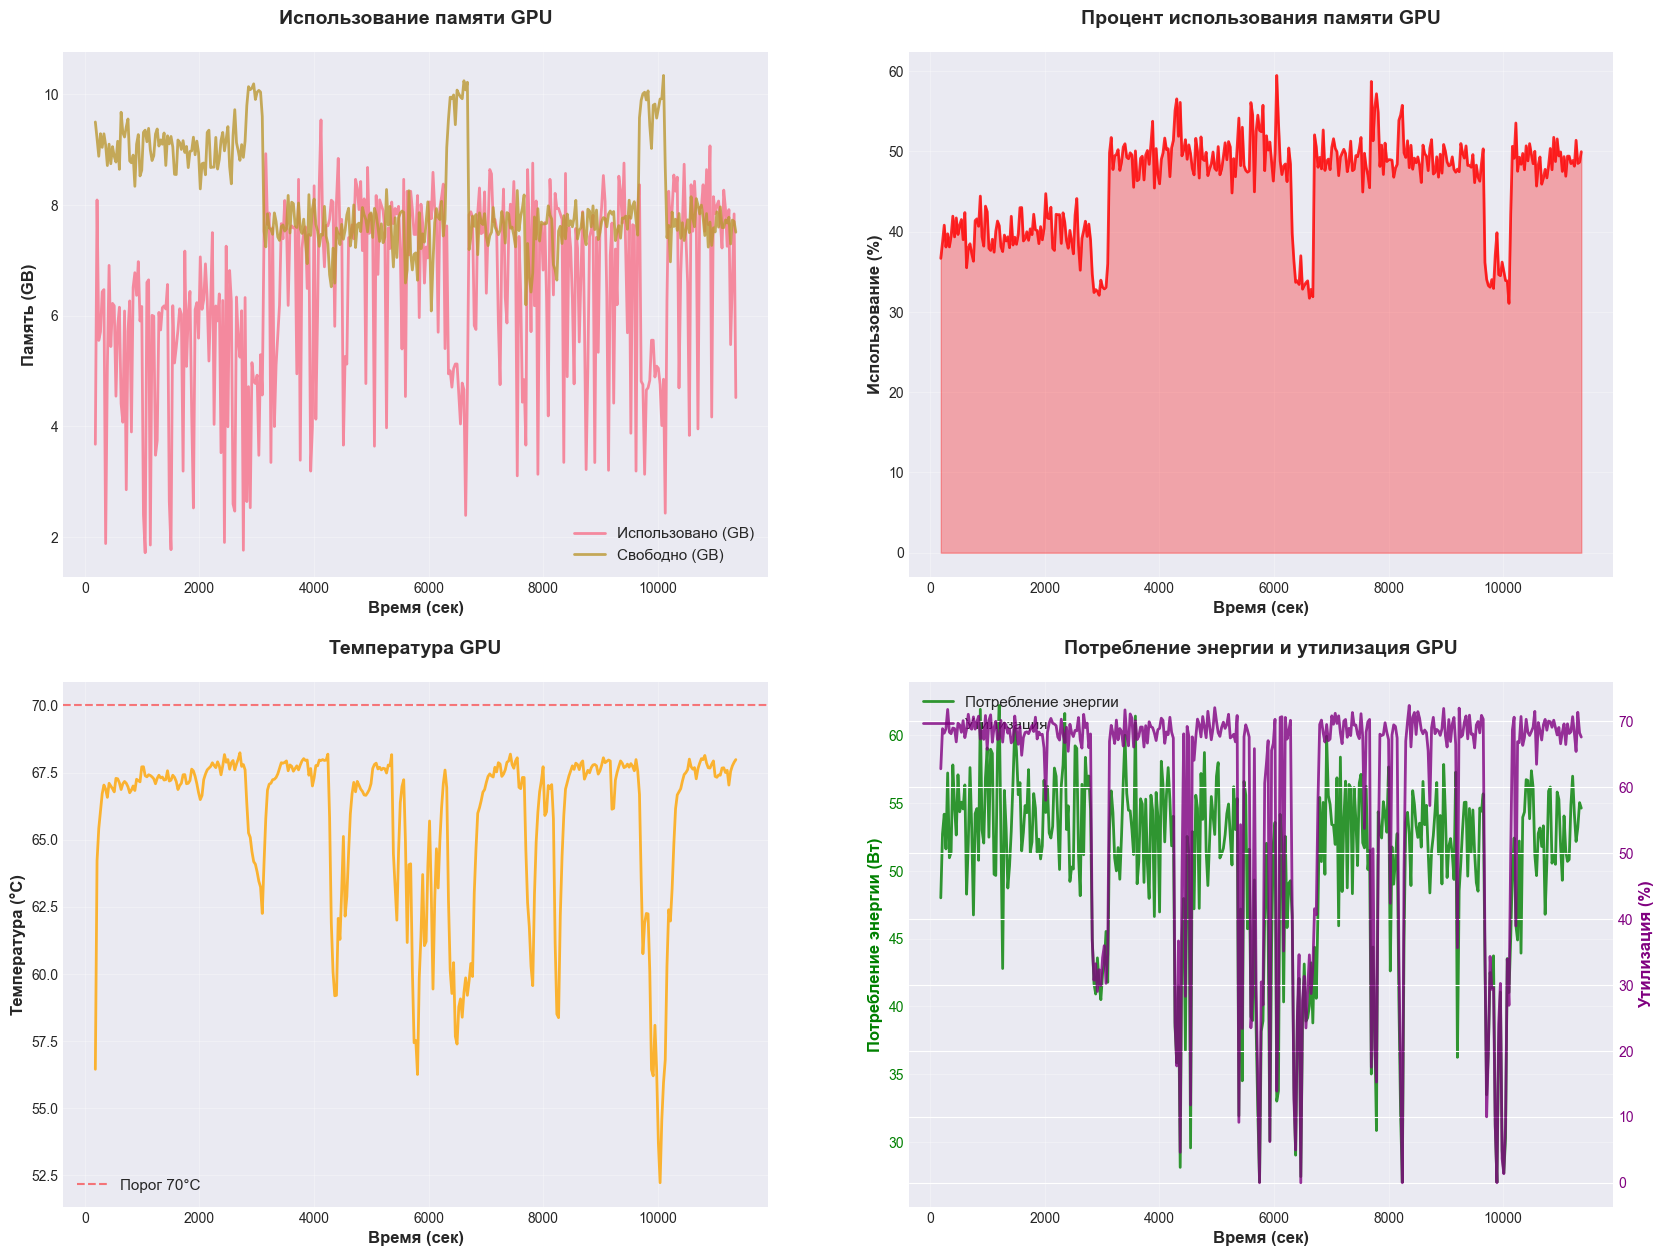

In [34]:
# Создание фигуры с тремя графиками
fig = plt.figure(figsize=(20, 15))

# 1. График использования GPU памяти и температуры
gs1 = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs1[0, 0])
ax2 = fig.add_subplot(gs1[0, 1])
ax3 = fig.add_subplot(gs1[1, 0])
ax4 = fig.add_subplot(gs1[1, 1])

# Извлечение данных GPU
gpu_metrics = {}
for series in gpu_data:
    name = series['name']
    x = series['x']
    y = series['y']
    gpu_metrics[name] = {'x': x, 'y': y}

# График 1: Использование памяти GPU
ax1.plot(gpu_metrics['gpu_0_mem_used_gb']['x'], 
         gpu_metrics['gpu_0_mem_used_gb']['y'], 
         linewidth=2, label='Использовано (GB)', alpha=0.8)
ax1.plot(gpu_metrics['gpu_0_mem_free_gb']['x'], 
         gpu_metrics['gpu_0_mem_free_gb']['y'], 
         linewidth=2, label='Свободно (GB)', alpha=0.8)
ax1.set_xlabel('Время (сек)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Память (GB)', fontsize=12, fontweight='bold')
ax1.set_title('Использование памяти GPU', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='best', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=10)

# График 2: Процент использования памяти
ax2.plot(gpu_metrics['gpu_0_mem_usage']['x'], 
         gpu_metrics['gpu_0_mem_usage']['y'], 
         linewidth=2, color='red', alpha=0.8)
ax2.set_xlabel('Время (сек)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Использование (%)', fontsize=12, fontweight='bold')
ax2.set_title('Процент использования памяти GPU', fontsize=14, fontweight='bold', pad=20)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=10)
ax2.fill_between(gpu_metrics['gpu_0_mem_usage']['x'], 
                 gpu_metrics['gpu_0_mem_usage']['y'], 
                 alpha=0.3, color='red')

# График 3: Температура GPU
ax3.plot(gpu_metrics['gpu_0_temperature']['x'], 
         gpu_metrics['gpu_0_temperature']['y'], 
         linewidth=2, color='orange', alpha=0.8)
ax3.set_xlabel('Время (сек)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Температура (°C)', fontsize=12, fontweight='bold')
ax3.set_title('Температура GPU', fontsize=14, fontweight='bold', pad=20)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', which='major', labelsize=10)
ax3.axhline(y=70, color='r', linestyle='--', alpha=0.5, label='Порог 70°C')
ax3.legend(loc='best', fontsize=11)

# График 4: Потребление энергии и утилизация
ax4_twin = ax4.twinx()
line1, = ax4.plot(gpu_metrics['gpu_0_power_draw']['x'], 
                  gpu_metrics['gpu_0_power_draw']['y'], 
                  linewidth=2, color='green', alpha=0.8, label='Потребление энергии')
line2, = ax4_twin.plot(gpu_metrics['gpu_0_utilization']['x'], 
                       gpu_metrics['gpu_0_utilization']['y'], 
                       linewidth=2, color='purple', alpha=0.8, label='Утилизация')
ax4.set_xlabel('Время (сек)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Потребление энергии (Вт)', fontsize=12, fontweight='bold', color='green')
ax4_twin.set_ylabel('Утилизация (%)', fontsize=12, fontweight='bold', color='purple')
ax4.set_title('Потребление энергии и утилизация GPU', fontsize=14, fontweight='bold', pad=20)
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='y', labelcolor='green')
ax4_twin.tick_params(axis='y', labelcolor='purple')
ax4.legend(handles=[line1, line2], loc='upper left', fontsize=11)

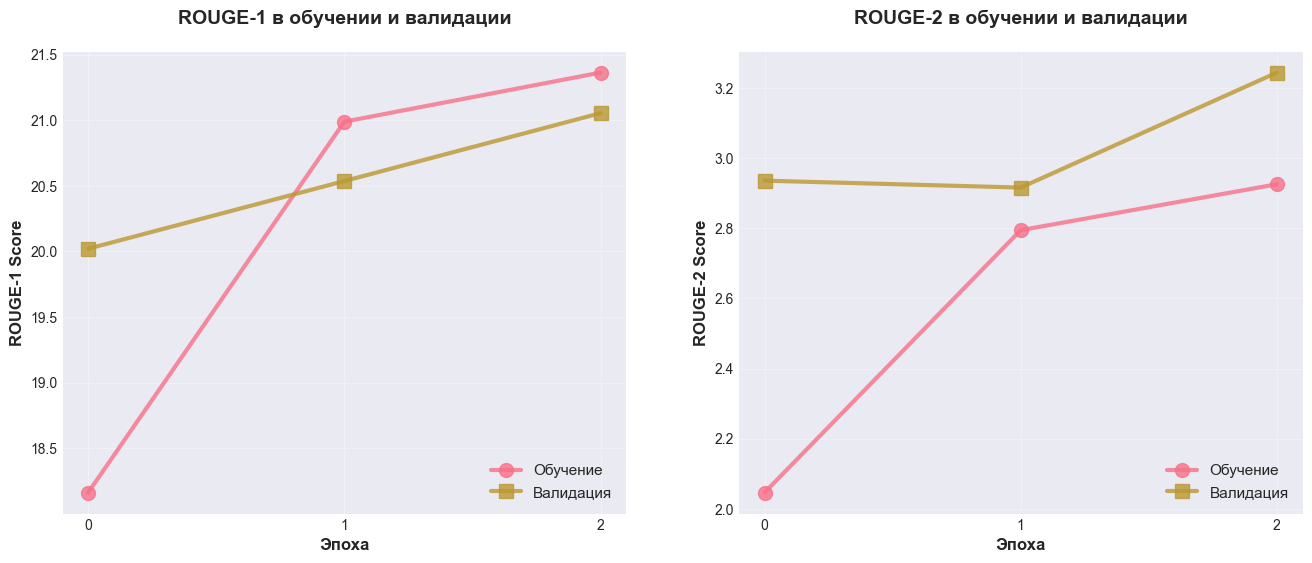

In [35]:
# 2. График метрик обучения и валидации (ROUGE)
fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(16, 6))

# Извлечение данных ROUGE
val_rouge1 = next(item for item in val_data if item["name"] == "ROUGE1")
val_rouge2 = next(item for item in val_data if item["name"] == "ROUGE2")
train_rouge1 = next(item for item in train_data if item["name"] == "ROUGE1")
train_rouge2 = next(item for item in train_data if item["name"] == "ROUGE2")

# График ROUGE-1
epochs = [0, 1, 2]
ax5.plot(epochs, train_rouge1['y'], marker='o', linewidth=3, markersize=10, 
         label='Обучение', alpha=0.8)
ax5.plot(epochs, val_rouge1['y'], marker='s', linewidth=3, markersize=10, 
         label='Валидация', alpha=0.8)
ax5.set_xlabel('Эпоха', fontsize=12, fontweight='bold')
ax5.set_ylabel('ROUGE-1 Score', fontsize=12, fontweight='bold')
ax5.set_title('ROUGE-1 в обучении и валидации', fontsize=14, fontweight='bold', pad=20)
ax5.legend(loc='lower right', fontsize=11)
ax5.grid(True, alpha=0.3)
ax5.set_xticks(epochs)
ax5.tick_params(axis='both', which='major', labelsize=10)

# График ROUGE-2
ax6.plot(epochs, train_rouge2['y'], marker='o', linewidth=3, markersize=10, 
         label='Обучение', alpha=0.8)
ax6.plot(epochs, val_rouge2['y'], marker='s', linewidth=3, markersize=10, 
         label='Валидация', alpha=0.8)
ax6.set_xlabel('Эпоха', fontsize=12, fontweight='bold')
ax6.set_ylabel('ROUGE-2 Score', fontsize=12, fontweight='bold')
ax6.set_title('ROUGE-2 в обучении и валидации', fontsize=14, fontweight='bold', pad=20)
ax6.legend(loc='lower right', fontsize=11)
ax6.grid(True, alpha=0.3)
ax6.set_xticks(epochs)
ax6.tick_params(axis='both', which='major', labelsize=10)


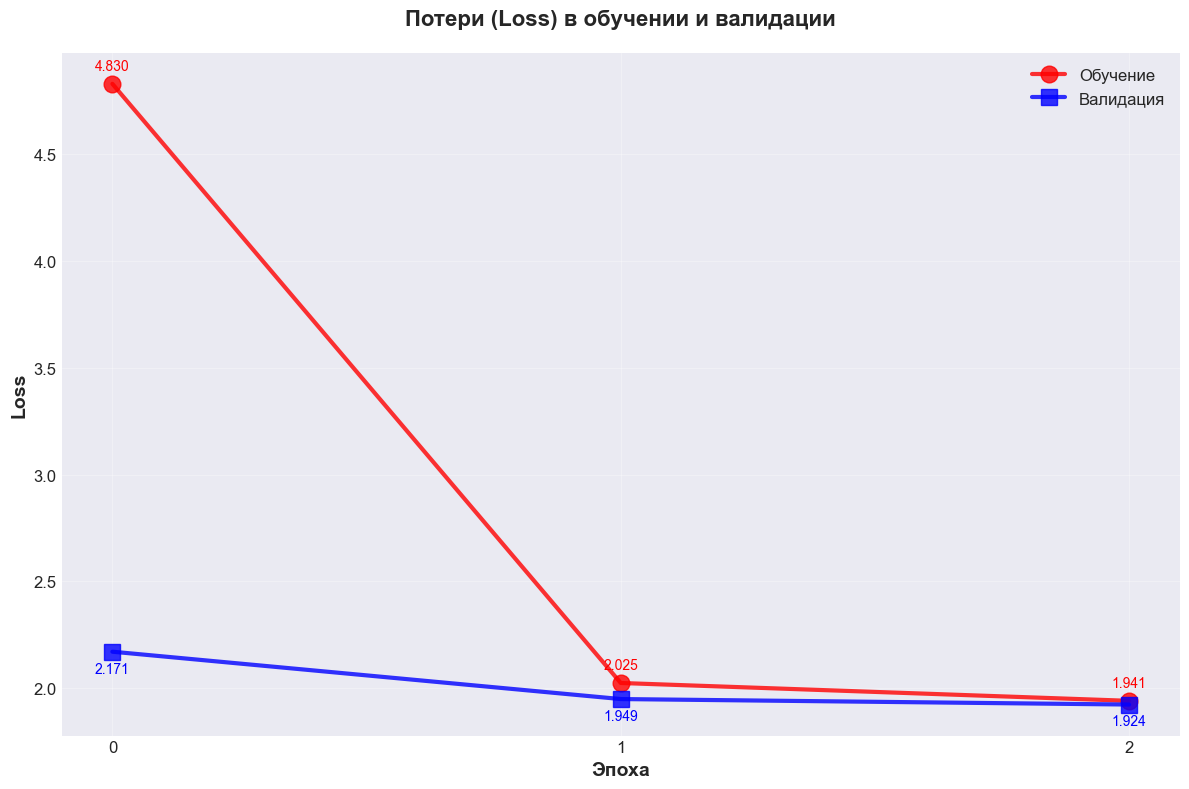

In [36]:
# 3. График потерь (loss)
fig3, ax7 = plt.subplots(figsize=(12, 8))

# Извлечение данных loss
val_loss = next(item for item in val_data if item["name"] == "loss")
train_loss = next(item for item in train_data if item["name"] == "loss")

# График потерь
ax7.plot(epochs, train_loss['y'], marker='o', linewidth=3, markersize=12, 
         label='Обучение', alpha=0.8, color='red')
ax7.plot(epochs, val_loss['y'], marker='s', linewidth=3, markersize=12, 
         label='Валидация', alpha=0.8, color='blue')
ax7.set_xlabel('Эпоха', fontsize=14, fontweight='bold')
ax7.set_ylabel('Loss', fontsize=14, fontweight='bold')
ax7.set_title('Потери (Loss) в обучении и валидации', fontsize=16, fontweight='bold', pad=20)
ax7.legend(loc='upper right', fontsize=12)
ax7.grid(True, alpha=0.3)
ax7.set_xticks(epochs)
ax7.tick_params(axis='both', which='major', labelsize=12)

# Добавление аннотаций с значениями
for i, (train_l, val_l) in enumerate(zip(train_loss['y'], val_loss['y'])):
    ax7.annotate(f'{train_l:.3f}', (epochs[i], train_l), 
                 textcoords="offset points", xytext=(0,10), 
                 ha='center', fontsize=10, color='red')
    ax7.annotate(f'{val_l:.3f}', (epochs[i], val_l), 
                 textcoords="offset points", xytext=(0,-15), 
                 ha='center', fontsize=10, color='blue')

# Настройка отступов и отображение
plt.tight_layout()
plt.show()

In [38]:
# Сохранение графиков
gpu_graph_path = os.path.join(graphs_dir, 'gpu_monitoring.png')
rouge_graph_path = os.path.join(graphs_dir, 'rouge_metrics.png')
loss_graph_path = os.path.join(graphs_dir, 'loss_metrics.png')

fig.savefig(gpu_graph_path, dpi=300, bbox_inches='tight')
fig2.savefig(rouge_graph_path, dpi=300, bbox_inches='tight')
fig3.savefig(loss_graph_path, dpi=300, bbox_inches='tight')

Демонстрация работы будет на этапе сравнения модели.
В процессе train вставлены некоторые оптимизации, поскольку у меня были большие проблемы с запуском модели на виртуальной машине, мне постоянно не хватало видеопамяти.

# Этап 4 и 5. Использование предобученного трансформера и формулирование выводов

In [13]:
from transformers import AutoModelForCausalLM
from src.eval_transformer_pipeline import transformer_generate

In [14]:
# Создаём модель
transformer_model_name = config['transformer_model']
print(f"Loading model: {transformer_model_name}")
transformer_model = AutoModelForCausalLM.from_pretrained(transformer_model_name).to(device)

transformer_model.resize_token_embeddings(len(tokenizer))

Loading model: distilgpt2


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(50258, 768)

In [27]:
weights_dir = os.path.join(project_root, 'models')
weights_path = os.path.join(weights_dir, config['weights'])
print(weights_path)
checkpoint = torch.load(weights_path, weights_only=False)

lstm_model.load_state_dict(checkpoint['model_state_dict'])
lstm_model = lstm_model.to(device)

C:\YandexNN\sprint_2\Project TextAutocomplete\models\best_weights_2.pth


In [28]:
def form_inference_data(x_seq, y_seq, tokenizer, device):
    "Формирует контексты (первые 3/4) и цели (последние 1/4) для инференса"
    
    pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    
    contexts = []
    targets = []
    
    for i in range(len(x_seq)):
        # Получаем i-й пример
        x_i = x_seq[i]
        y_i = y_seq[i]
        
        # Находим реальные длины (без паддинга)
        x_len = (x_i != pad_token_id).sum().item()
        y_len = (y_i != pad_token_id).sum().item()
        
        # Берем только реальные токены
        x_real = x_i[:x_len]
        y_real = y_i[:y_len]
        
        # Восстанавливаем полное сообщение
        if len(x_real) > 0 and len(y_real) > 0:
            # Полное сообщение: [x_real[0]] + y_real
            full_message = torch.cat([x_real[:1], y_real])
        else:
            continue
        
        # Вычисляем split point
        full_len = len(full_message)
        split_idx = int(0.75 * (full_len + 1))
        split_idx = min(split_idx, full_len - 1)
        split_idx = max(1, split_idx)
        
        # Разделяем
        context = full_message[:split_idx]
        target = full_message[split_idx:]
        
        contexts.append(context)
        targets.append(target)
    
    if len(contexts) == 0:
        return torch.empty((0, 0), dtype=torch.long).to(device), []
    
    # Создаем тензор с паддингом
    max_context_len = max([len(ctx) for ctx in contexts])
    context_tensor = torch.full((len(contexts), max_context_len), 
                               pad_token_id, dtype=torch.long).to(device)
    
    for i, ctx in enumerate(contexts):
        context_tensor[i, :len(ctx)] = ctx

    return context_tensor, targets

In [33]:
# Основной цикл сравнения
all_transformer_hypotheses = []
all_lstm_hypotheses = []
all_references = []

batch_counter = 0
total_batches = len(test_loader)

for batch in test_loader:
    batch_counter += 1
    if batch_counter == 10: break
    print(f"\nОбработка батча {batch_counter}/{total_batches}")
    
    x_seq = batch['input_seq'].to(device)
    lengths = batch['lengths']
    y_seq = batch['target_seq'].to(device)

    context_tensor, targets = form_inference_data(x_seq, y_seq, tokenizer, device)
    
    # Генерируем продолжение
    print("Генерация Transformer...")
    transformer_output = transformer_generate(transformer_model, tokenizer, context_tensor, device)
    
    print("Генерация LSTM...")
    # lstm_output_tokens = lstm_model.generate(context_tensor) <- генерирует только точку
    lstm_output_tokens, _ = lstm_model.forward(context_tensor)
    lstm_output_tokens = torch.argmax(lstm_output_tokens, dim=-1)
    
    lstm_output = tokenizer.batch_decode(lstm_output_tokens, skip_special_tokens=True)
    
    # Декодируем контексты и цели для отображения
    context_texts = tokenizer.batch_decode(context_tensor, skip_special_tokens=True)
    
    # Декодируем цели
    target_texts = []
    for target in targets:
        target_texts.append(tokenizer.decode(target, skip_special_tokens=True))
    
    # Сохраняем для вычисления метрик
    all_transformer_hypotheses.extend(transformer_output)
    all_lstm_hypotheses.extend(lstm_output)
    all_references.extend(target_texts)
    
    # Выводим результаты для первых 3 примеров в каждом батче
    print("\nПримеры из батча:")
    for i, (context_text, transformer_text, lstm_text, target_text) in enumerate(
        zip(context_texts[:3], transformer_output[:3], lstm_output[:3], target_texts[:3])
    ):
        print(f"\nПример {i+1}:")
        print(f"Контекст (3/4): '{context_text}'")
        print(f"Transformer: '{transformer_text}'")
        print(f"LSTM: '{lstm_text}'")
        print(f"Цель (1/4): '{target_text}'")
        print("-" * 50)


Обработка батча 1/1248


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Генерация Transformer...
Input IDs shape: torch.Size([128, 29])
Attention mask shape: torch.Size([128, 29])
Max input ID: 50257
Vocab size: 50258


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Генерация LSTM...

Примеры из батча:

Пример 1:
Контекст (3/4): 'at my parents house i found my old cats cradle string in my sisters room and my mom and i were trying'
Transformer: ' i was so tired my mom was always crying her'
LSTM: ' the house.wives'm out last friends.. the head.. i head is i'm going to.......'
Цель (1/4): ' to remember how to do everything'
--------------------------------------------------

Пример 2:
Контекст (3/4): 'nope it certainly wasn't'
Transformer: ' on their side.



“'
LSTM: 'ope,'s is't a.......................'
Цель (1/4): ' quiet'
--------------------------------------------------

Пример 3:
Контекст (3/4): 'school will be online soon homie!! they are working inside the building to'
Transformer: ' our amazement...'
LSTM: ' is be a tomorrowie!'re so on day. the..............'
Цель (1/4): ' make the conversion now'
--------------------------------------------------

Обработка батча 2/1248
Генерация Transformer...
Input IDs shape: torch.Size([128, 29])
Att

...

Генерация LSTM...

Примеры из батча:

Пример 1:
Контекст (3/4): 'comp. theory was my 2nd favorite class behind theory of programming languages. part of why'
Transformer: ' made this a fun course? It was also one'
LSTM: 'etitioni, a firstnd time of. the. the.. of the i???.........'
Цель (1/4): ' i love f .'
--------------------------------------------------

Пример 2:
Контекст (3/4): 'oh ok!!!!...have a great time tomm nite!!!!! good luck in'
Transformer: '!!!!!!!! i can't wait to get out and enjoy'
LSTM: ' no, i i a great day! getorite night with the..............'
Цель (1/4): ' finding the flats!'
--------------------------------------------------

Пример 3:
Контекст (3/4): 'i donated 20 last night love your song'
Transformer: ' for me so I can be proud to say it'
LSTM: ''m to minutes night. you new.....................'
Цель (1/4): '!'
--------------------------------------------------

Обработка батча 7/1248
Генерация Transformer...
Input IDs shape: torch.Size([128, 36])
Attention m

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Генерация LSTM...

Примеры из батча:

Пример 1:
Контекст (3/4): 'can volunteers get a discount or something on the shirt? ;) btw we loved u amp; u were awesome'
Transformer: '.
A lot of other people have asked that'
LSTM: ''t to the new for something to the way.tw,'re it!; i guys here!............'
Цель (1/4): ' to us in va beach!!!!'
--------------------------------------------------

Пример 2:
Контекст (3/4): 'i'm in ur sims talking nerd to'
Transformer: '. I hope you don't be like me,'
LSTM: ''m so the ways 3 about. me...........................'
Цель (1/4): ' ur neighbourhood'
--------------------------------------------------

Пример 3:
Контекст (3/4): 'starbucks is my truel'
Transformer: ' for the best of my time!

I'
LSTM: ' trek, a favoriteampa..............................'
Цель (1/4): 'ove'
--------------------------------------------------

Обработка батча 8/1248
Генерация Transformer...
Input IDs shape: torch.Size([128, 27])
Attention mask shape: torch.Size([128, 27])
Max i

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Генерация LSTM...

Примеры из батча:

Пример 1:
Контекст (3/4): 'it's true does luv popcorn more than than anythin now that i think about evrythin except'
Transformer: ' does it really matter how it looks.

'
LSTM: ''s a. notuv the. than ix of i'm i itry me....'
Цель (1/4): ' 4 beep :p'
--------------------------------------------------

Пример 2:
Контекст (3/4): 'it is just an illusion after'
Transformer: 'ism.'
LSTM: ''s a a hour and a.....................'
Цель (1/4): 'all'
--------------------------------------------------

Пример 3:
Контекст (3/4): 'love ya!!! happy day! drink up'
Transformer: '.'
LSTM: 'ly! birthday!in with.................'
Цель (1/4): '.'
--------------------------------------------------

Обработка батча 9/1248
Генерация Transformer...
Input IDs shape: torch.Size([128, 27])
Attention mask shape: torch.Size([128, 27])
Max input ID: 50257
Vocab size: 50258
Генерация LSTM...

Примеры из батча:

Пример 1:
Контекст (3/4): 'the full moon tonight is amazing. almost l

In [34]:
from src.eval_lstm import calculate_rouge_metrics

In [35]:
# Метрики для Transformer
print("\n--- Transformer ---")
transformer_rouge = calculate_rouge_metrics(all_transformer_hypotheses, all_references)
print(f"ROUGE-1: {transformer_rouge['rouge1']:.2f}%")
print(f"ROUGE-2: {transformer_rouge['rouge2']:.2f}%")

# Метрики для LSTM
print("\n--- LSTM ---")
lstm_rouge = calculate_rouge_metrics(all_lstm_hypotheses, all_references)
print(f"ROUGE-1: {lstm_rouge['rouge1']:.2f}%")
print(f"ROUGE-2: {lstm_rouge['rouge2']:.2f}%")

# Сравнение
print("\n--- Сравнение ---")
print(f"Разница ROUGE-1: {transformer_rouge['rouge1'] - lstm_rouge['rouge1']:.2f}%")
print(f"Разница ROUGE-2: {transformer_rouge['rouge2'] - lstm_rouge['rouge2']:.2f}%")

# Статистика
print(f"\n--- Статистика ---")
print(f"Всего примеров: {len(all_references)}")
print(f"Средняя длина цели: {sum(len(t) for t in all_references) / len(all_references):.1f} символов")


--- Transformer ---
ROUGE-1: 1.93%
ROUGE-2: 0.12%

--- LSTM ---
ROUGE-1: 3.20%
ROUGE-2: 0.03%

--- Сравнение ---
Разница ROUGE-1: -1.27%
Разница ROUGE-2: 0.09%

--- Статистика ---
Всего примеров: 1152
Средняя длина цели: 11.1 символов


# Вывод

Качественно и количественно LSTM модель значительно уступает Transformer архитектуре. 

На столь сложных данных с неформальным языком общения модель явно не доучилась, демонстрируя однако в процессе обучения положительную динамику. Однако LSTM модель справляется лучше в задаче предсказания хотя бы одного верного следующего слова, что потенциально делают её более подходящей для интеграции. Требуются дополнительные ресурсы для обучения, поскольку модель смогла отучится всего лишь на 3 эпохах.

**Резюме:** адаптировать ресурсы под gpt по крайней мере на данном этапе обучения LSTM. 